<a href="https://colab.research.google.com/github/IqbaLe0/Hoax-News-Classification/blob/main/Hoax_Detection_SBERT_TreeModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasifikasi Berita Hoax vs Faktual (Bahasa Indonesia)
### Pendekatan: Sentence-BERT Embedding + Tree-Based Models (LightGBM, XGBoost, CatBoost)

Notebook ini merupakan pipeline **end-to-end** untuk penelitian klasifikasi berita:

- **Kelas 0 (Faktual)**: `dataset_cnn_10k.xlsx`, `dataset_tempo_6k.xlsx`, `dataset_kompas_4k.xlsx`
- **Kelas 1 (Hoax)**: `dataset_turnbackhoax_10k.xlsx`

**Alur pipeline:**
1. Data Loading & Integration
2. Text Preprocessing (dengan penanganan khusus untuk artefak struktural TurnBackHoax)
3. Text Embedding (Sentence-BERT multilingual)
4. Train-Test Split (stratified 80:20)
5. Model Training (LightGBM, XGBoost, CatBoost)
6. Hyperparameter Tuning (Optuna)
7. Evaluation Metrics
8. Model Comparison
9. Visualization
10. Kesimpulan
11. Bonus: Imbalance handling, penyimpanan model, fungsi inferensi

> **Catatan penting sebelum mulai:** Notebook ini dirancang agar *runnable end-to-end* di Google Colab. Aktifkan **GPU runtime** (`Runtime > Change runtime type > T4 GPU`) agar proses embedding SBERT jauh lebih cepat. Beberapa sel memiliki *flag* (`RUN_FULL_STEMMING`, `RUN_SMOTE`, dll.) yang bisa diaktifkan/nonaktifkan sesuai kebutuhan waktu eksekusi.


## 0. Setup & Instalasi Library

Sel di bawah menginstal seluruh dependency yang dibutuhkan. Di Google Colab, sebagian besar library dasar (pandas, numpy, scikit-learn, matplotlib, seaborn) sudah tersedia, sehingga kita hanya perlu menambahkan library yang spesifik untuk NLP Bahasa Indonesia, embedding, dan model tree-based.

In [1]:
# %%capture
!pip install -q sentence-transformers==3.0.1
!pip install -q lightgbm xgboost catboost
!pip install -q optuna
!pip install -q Sastrawi
!pip install -q imbalanced-learn
!pip install -q openpyxl
print("Instalasi selesai.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 47.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.6 MB/s eta 0:00:00
Instalasi selesai.


In [2]:
import os
import re
import json
import time
import warnings
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


**Cek ketersediaan GPU** (opsional tapi sangat disarankan untuk mempercepat proses embedding SBERT):

In [3]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device yang digunakan: {DEVICE}")
if DEVICE == "cpu":
    print("PERINGATAN: GPU tidak terdeteksi. Proses embedding akan lebih lambat. "
          "Disarankan mengaktifkan GPU melalui Runtime > Change runtime type > T4 GPU.")

Device yang digunakan: cuda


## 1. Data Loading & Integration

### 1.1 Upload dataset

Jalankan sel di bawah untuk mengunggah 4 file dataset (`.xlsx`). Jika Anda menjalankan notebook ini di Google Colab dengan file yang sudah ada di Google Drive, gunakan opsi Google Drive (sel alternatif disediakan, tinggal uncomment).

Nama file default mengikuti nama file asli Anda:
- `dataset_cnn_10k.xlsx` &rarr; Faktual
- `dataset_kompas_4k.xlsx` &rarr; Faktual
- `dataset_tempo_6k.xlsx` &rarr; Faktual
- `dataset_turnbackhoax_10k.xlsx` &rarr; Hoax

Sesuaikan `CONFIG["files"]` di bawah apabila nama file Anda berbeda.

In [4]:
CONFIG = {
    "files": {
        "cnn": "dataset_cnn_10k.xlsx",
        "kompas": "dataset_kompas_4k.xlsx",
        "tempo": "dataset_tempo_6k.xlsx",
        "turnbackhoax": "dataset_turnbackhoax_10k.xlsx",
    },
    "label_map": {          # 0 = Faktual, 1 = Hoax
        "cnn": 0,
        "kompas": 0,
        "tempo": 0,
        "turnbackhoax": 1,
    },
    "data_dir": ".",
}

### 1.2 Load & gabungkan dataset

Setiap file memiliki kolom yang sama: `Title`, `Timestamp`, `FullText`, `Tags`, `Author`, `Url`. Kita hanya akan menggunakan `Title` dan `FullText` sebagai sumber teks utama, sisanya disimpan sebagai metadata (`source`, `label`).

In [9]:
SAMPLE_SIZE = {
    "cnn": 1000,
    "kompas": 1000,
    "tempo": 1000,
    "turnbackhoax": 3000,
}

def load_source(key):
    path = os.path.join(CONFIG["data_dir"], CONFIG["files"][key])
    df = pd.read_excel(path)

    df["source"] = key
    df["label"] = CONFIG["label_map"][key]

    n = SAMPLE_SIZE[key]

    # kalau mau random sampling (recommended)
    df = df.sample(n=min(n, len(df)), random_state=42).reset_index(drop=True)

    return df

dfs = {key: load_source(key) for key in CONFIG["files"]}

for key, df in dfs.items():
    print(f"{key:15s} -> {df.shape[0]:>6d} baris, {df.shape[1]} kolom")

cnn             ->   1000 baris, 8 kolom
kompas          ->   1000 baris, 8 kolom
tempo           ->   1000 baris, 8 kolom
turnbackhoax    ->   3000 baris, 8 kolom


### 1.3 Penanganan khusus TurnBackHoax: verifikasi label dari tag verdict pada judul

**Temuan penting:** Judul artikel TurnBackHoax memiliki tag verdict di awal, misalnya `[SALAH]`, `[BENAR]`, `[KLARIFIKASI]`, `[DISINFORMASI]`, dsb. Tag ini **bukan sekadar noise** — tag tersebut menunjukkan **hasil verifikasi fakta**, dan tidak semua artikel di situs TurnBackHoax berkesimpulan "hoax"!

Contoh: tag `[BENAR]` berarti klaim yang diperiksa **terbukti benar** (bukan hoax), dan tag seperti `[BERITA]`, `[EDUKASI]`, `[ACARA]` bukan merupakan verdict fact-check sama sekali (melainkan artikel non-verifikasi di situs yang sama). Jika seluruh baris TurnBackHoax dipukul rata sebagai label `1 (Hoax)`, akan terjadi **label noise** yang bisa merusak validitas hasil klasifikasi.

Oleh karena itu, kita ekstrak tag dari judul, lalu **hanya mempertahankan artikel dengan verdict yang benar-benar menyatakan hoax/false/disinformasi**, dan membuang baris dengan verdict ambigu atau berlawanan.

In [10]:
def extract_verdict_tag(title):
    if not isinstance(title, str):
        return None
    m = re.match(r"^\s*\[([^\]]+)\]", title)
    return m.group(1).strip().upper() if m else None

tbh = dfs["turnbackhoax"].copy()
tbh["verdict_tag"] = tbh["Title"].apply(extract_verdict_tag)

print("Distribusi tag verdict pada dataset TurnBackHoax:")
print(tbh["verdict_tag"].value_counts(dropna=False))

Distribusi tag verdict pada dataset TurnBackHoax:
verdict_tag
SALAH                       2308
None                         161
BENAR                        131
HOAX                         115
KLARIFIKASI                   91
DISINFORMASI                  54
BERITA                        52
FALSE                         35
TOP 5                         10
EDUKASI                       10
ACARA                          5
HOAKS                          4
MISINFORMASI                   4
ISU                            3
ADMIN POST                     2
FITNAH                         2
EVENT                          1
BERITA, EDUKASI                1
CEKFAKTA                       1
EDUKASI, HOAX                  1
DOKUMENTASI                    1
RILIS PERS                     1
SIARAN PERS                    1
DISINFORMASI, HASUT            1
HOAX/FITNAH                    1
HOAX, HASUT, & PROVOKASI       1
SCAM                           1
INFORMASI                      1
HASUT         

In [11]:
# Tag yang benar-benar menyatakan konten sebagai HOAX/FALSE/DISINFORMASI
HOAX_VERDICT_TAGS = {
    "SALAH", "HOAX", "HOAKS", "DISINFORMASI", "FALSE",
    "MISINFORMASI", "FITNAH", "HASUT", "PENIPUAN"
}

before = len(tbh)
tbh_filtered = tbh[tbh["verdict_tag"].isin(HOAX_VERDICT_TAGS)].copy()
after = len(tbh_filtered)

print(f"TurnBackHoax sebelum filter verdict : {before} baris")
print(f"TurnBackHoax sesudah filter verdict : {after} baris")
print(f"Baris yang dibuang (verdict non-hoax/ambigu): {before - after} baris")
print()
print("Rincian baris yang dibuang (per tag):")
print(tbh.loc[~tbh["verdict_tag"].isin(HOAX_VERDICT_TAGS), "verdict_tag"].value_counts(dropna=False))

dfs["turnbackhoax"] = tbh_filtered

TurnBackHoax sebelum filter verdict : 3000 baris
TurnBackHoax sesudah filter verdict : 2523 baris
Baris yang dibuang (verdict non-hoax/ambigu): 477 baris

Rincian baris yang dibuang (per tag):
verdict_tag
None                        161
BENAR                       131
KLARIFIKASI                  91
BERITA                       52
TOP 5                        10
EDUKASI                      10
ACARA                         5
ISU                           3
ADMIN POST                    2
EVENT                         1
BERITA, EDUKASI               1
CEKFAKTA                      1
EDUKASI, HOAX                 1
DOKUMENTASI                   1
RILIS PERS                    1
SIARAN PERS                   1
DISINFORMASI, HASUT           1
HOAX/FITNAH                   1
HOAX, HASUT, & PROVOKASI      1
SCAM                          1
INFORMASI                     1
Name: count, dtype: int64


### 1.4 Menggabungkan seluruh sumber menjadi satu DataFrame

In [12]:
cols_needed = ["Title", "FullText", "source", "label"]
combined = pd.concat([dfs[k][cols_needed] for k in dfs], ignore_index=True)
combined = combined.rename(columns={"Title": "title", "FullText": "fulltext"})

print("Total gabungan sebelum cleaning:", combined.shape)
combined.head()

Total gabungan sebelum cleaning: (5523, 4)


,title,fulltext,source,label
0,Jokowi Bicara Reshuffle Menteri saat Beri Arah...,"Jakarta, CNN Indonesia -- Presiden Joko Widodo...",cnn,0
1,"Usai Jumpa PKS, NasDem Bertemu Demokrat Besok","Jakarta, CNN Indonesia -- NasDem bakal bertemu...",cnn,0
2,"PKS Sebut Revisi UU IKN Terburu-buru, Demokrat...","Jakarta, CNN Indonesia -- Mayoritas fraksi di ...",cnn,0
3,Mega di Depan Ganjar: Hanya Ketua Umum yang Me...,"Jakarta, CNN Indonesia -- Calon presiden (capr...",cnn,0
4,Yenny Wahid Bongkar Sejarah Kelam Cak Imin Vs ...,"Jakarta, CNN Indonesia -- Zannuba Ariffah Chaf...",cnn,0


### 1.5 Cek missing value, duplikat, dan imbalance kelas

In [13]:
print("=== Missing value per kolom ===")
print(combined.isnull().sum())
print()
print("=== Jumlah baris dengan fulltext kosong/NaN ===")
print(combined["fulltext"].isnull().sum())

=== Missing value per kolom ===
title        6
fulltext    42
source       0
label        0
dtype: int64

=== Jumlah baris dengan fulltext kosong/NaN ===
42


In [14]:
# Buang baris dengan title/fulltext kosong (tidak bisa digunakan untuk klasifikasi teks)
combined = combined.dropna(subset=["title", "fulltext"]).reset_index(drop=True)
print("Shape setelah membuang missing value:", combined.shape)

Shape setelah membuang missing value: (5481, 4)


In [15]:
dup_count = combined.duplicated(subset=["fulltext"]).sum()
print(f"Jumlah duplikat (berdasarkan fulltext): {dup_count}")

combined = combined.drop_duplicates(subset=["fulltext"]).reset_index(drop=True)
print("Shape setelah membuang duplikat:", combined.shape)

Jumlah duplikat (berdasarkan fulltext): 4
Shape setelah membuang duplikat: (5477, 4)


=== Distribusi label ===
label
0    2958
1    2519
Name: count, dtype: int64

=== Proporsi kelas ===
label
0    0.54
1    0.46
Name: proportion, dtype: float64


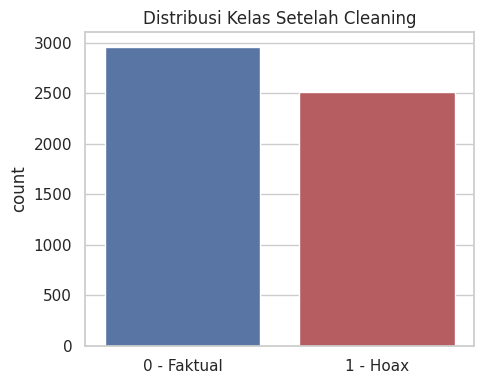

In [16]:
print("=== Distribusi label ===")
print(combined["label"].value_counts())
print()
print("=== Proporsi kelas ===")
print(combined["label"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=combined, x="label", palette=["#4C72B0", "#C44E52"], ax=ax)
ax.set_xticklabels(["0 - Faktual", "1 - Hoax"])
ax.set_title("Distribusi Kelas Setelah Cleaning")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Insight:** Rasio kelas berkisar sekitar 1.2:1 sampai 1.5:1 (Faktual : Hoax) tergantung hasil filtering verdict di atas — ini termasuk **imbalance ringan**, bukan ekstrem. Kita akan menanganinya melalui `class_weight` / `scale_pos_weight` pada model tree-based (lihat bagian Bonus), yang lebih sesuai untuk fitur embedding dense dibanding oversampling seperti SMOTE.

## 2. Text Preprocessing

### Catatan metodologis penting

Pipeline ini menggunakan **Sentence-BERT (SBERT)** untuk embedding — model transformer yang sudah dipre-train pada teks alami. Praktik terbaik yang didukung literatur NLP (Reimers & Gurevych, 2019 dan riset lanjutannya) menyatakan bahwa **stemming dan stopword removal justru dapat menurunkan kualitas representasi** embedding transformer, karena:

1. Model transformer memanfaatkan **konteks kalimat utuh** (urutan kata, imbuhan, kata tugas) untuk membangun makna semantik.
2. Stemming memotong imbuhan Bahasa Indonesia (mis. "diberitakan" &rarr; "berita") yang justru membawa informasi gramatikal.
3. Stopword removal dapat merusak struktur kalimat yang menjadi dasar attention mechanism pada model transformer.

Karena itu, kita membangun **dua jalur preprocessing**:

| Jalur | Langkah | Digunakan untuk |
|---|---|---|
| **`text_clean`** (ringan) | lowercasing, hapus URL/angka/simbol, hapus boilerplate struktural, normalisasi spasi | **Input embedding SBERT** (jalur utama) |
| **`text_processed`** (lengkap) | + tokenization, stopword removal, stemming (Sastrawi) | Demonstrasi/eksplorasi sesuai kebutuhan tugas; **tidak dipakai untuk SBERT** |

Pendekatan ini memenuhi seluruh checklist preprocessing NLP klasik sekaligus menjaga kualitas embedding semantik.

In [17]:
def strip_title_tag(title):
    '''Menghapus tag verdict di awal judul TurnBackHoax, mis. '[SALAH] ...' -> '...'
    Tag ini sengaja dihapus karena merupakan sinyal trivial (data leakage):
    model bisa 'curang' hanya dengan mendeteksi pola '[' di awal judul,
    alih-alih benar-benar mempelajari konten semantik berita.
    '''
    if not isinstance(title, str):
        return ""
    return re.sub(r"^\s*\[[^\]]*\]\s*", "", title).strip()


def clean_tbh_structure(text):
    '''Menghapus artefak struktural khas artikel fact-check TurnBackHoax:
    - baris 'Hasil Periksa Fakta <nama> (<institusi>)'
    - baris pemisah '====='
    - section metadata [KATEGORI]/[SUMBER]/[REFERENSI] beserta isinya (kategori, platform sumber, URL referensi)
    - tag [NARASI]/[PENJELASAN] dibuang, namun ISI di dalamnya dipertahankan (ini konten inti)
    - baris 'Editor: ...' di akhir artikel
    - URL mentah
    '''
    if not isinstance(text, str):
        return ""

    skip_sections = {"KATEGORI", "SUMBER", "REFERENSI"}
    keep_sections = {"NARASI", "PENJELASAN"}

    lines = text.split("\n")
    out_lines = []
    current_skip = False

    for line in lines:
        stripped = line.strip()

        header_match = re.match(r"^\[([A-Za-z ]+)\]\s*:?", stripped)
        if header_match:
            sec = header_match.group(1).strip().upper()
            if sec in skip_sections:
                current_skip = True
                continue
            elif sec in keep_sections:
                current_skip = False
                remainder = stripped[header_match.end():].strip(": ").strip()
                if remainder:
                    out_lines.append(remainder)
                continue
            else:
                current_skip = False
                continue

        if current_skip:
            continue
        if re.match(r"^Hasil Periksa Fakta", stripped, flags=re.IGNORECASE):
            continue
        if re.fullmatch(r"=+", stripped):
            continue
        if re.match(r"^Editor\s*:", stripped, flags=re.IGNORECASE):
            continue
        if re.match(r"^https?://", stripped):
            continue

        out_lines.append(line)

    return "\n".join(out_lines)


def clean_generic_boilerplate(text, source):
    '''Menghapus artefak spesifik-portal yang tidak relevan terhadap konten:
    - CNN: 'ADVERTISEMENT', 'SCROLL TO RESUME CONTENT', marker 'Lihat Juga :'
    - Kompas: kredit video ('Video Jurnalis:', 'Video Editor:', dst.), hashtag, kalimat teaser video
    '''
    if not isinstance(text, str):
        return ""

    if source == "cnn":
        text = re.sub(r"ADVERTISEMENT", " ", text, flags=re.IGNORECASE)
        text = re.sub(r"SCROLL TO RESUME CONTENT", " ", text, flags=re.IGNORECASE)
        text = re.sub(r"Lihat Juga\s*:", " ", text, flags=re.IGNORECASE)

    if source == "kompas":
        text = re.sub(r"Video (Jurnalis|Editor|Produser|Narator)\s*:.*", " ", text, flags=re.IGNORECASE)
        text = re.sub(r"Simak selengkapnya dalam video berikut\.?", " ", text, flags=re.IGNORECASE)
        text = re.sub(r"#\w+", " ", text)
        text = re.sub(r"Music\s*:.*", " ", text, flags=re.IGNORECASE)

    return text


def general_clean(text):
    '''Cleaning umum: lowercasing, hapus URL, angka, simbol/tanda baca, normalisasi spasi.'''
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


print("Fungsi preprocessing berhasil didefinisikan.")

Fungsi preprocessing berhasil didefinisikan.


In [18]:
def build_text_clean(row):
    title = strip_title_tag(row["title"]) if row["source"] == "turnbackhoax" else row["title"]
    body = row["fulltext"]

    if row["source"] == "turnbackhoax":
        body = clean_tbh_structure(body)
    else:
        body = clean_generic_boilerplate(body, row["source"])

    raw_combined = f"{title}. {body}"
    return general_clean(raw_combined)


combined["text_clean"] = combined.apply(build_text_clean, axis=1)

# Buang baris yang menjadi kosong setelah cleaning (mis. artikel tanpa isi bermakna)
before_clean = len(combined)
combined = combined[combined["text_clean"].str.split().str.len() >= 5].reset_index(drop=True)
print(f"Baris dibuang karena teks terlalu pendek/kosong setelah cleaning: {before_clean - len(combined)}")
print("Shape akhir dataset:", combined.shape)

Baris dibuang karena teks terlalu pendek/kosong setelah cleaning: 0
Shape akhir dataset: (5477, 5)


**Contoh hasil cleaning** (bandingkan teks asli vs `text_clean`):

In [19]:
sample_idx = combined[combined["source"] == "turnbackhoax"].sample(1, random_state=SEED).index[0]
print("--- RAW (fulltext asli, dipotong 800 karakter) ---")
print(combined.loc[sample_idx, "fulltext"][:800])
print()
print("--- CLEANED (text_clean, dipotong 800 karakter) ---")
print(combined.loc[sample_idx, "text_clean"][:800])

--- RAW (fulltext asli, dipotong 800 karakter) ---
Hasil periksa fakta Fathia IS.
Informasi tersebut keliru. Faktanya, sampai saat ini akun Donald Trump masih ditangguhkan.
Selengkapnya di bagian penjelasan dan referensi.
= = =Kategori: Konten Palsu
= = =Sumber: Facebookhttps://perma.cc/EC99-YMHS?type=image

= ==Narasi dalam Tangkapan Layar:“It’s good to be back, Thanks Elon!”
= = =Penjelasan:Unggahan di Facebook membagikan tangkapan layar twitter yang menunjukkan tweet dari akun Donald Trump (@realDonaldTrump) yang berterima kasih kepada Elon Musk karena mengizinkannya bergabung kembali dengan Twitter. Dalam tangkapan layar tersebut terlihat Donald Trump mengunggah tweet pada tanggal 15 April 2022.
Tangkapan layar yang disebar ulang di Facebook tersebut mendapatkan atensi cukup tinggi dengan total komentar 180+.
Setelah ditelusuri informa

--- CLEANED (text_clean, dipotong 800 karakter) ---
elon musk mengaktifkan kembali twitter donald trump informasi tersebut keliru faktanya sampai s

## 3. Text Embedding (Sentence-BERT)

### Pemilihan model

Kita menggunakan **`paraphrase-multilingual-MiniLM-L12-v2`** dari library `sentence-transformers`, dengan alasan:

- **Gratis & open-source**, dapat dijalankan langsung dari HuggingFace Hub.
- **Multilingual**: dilatih dengan knowledge distillation dari model teacher berbahasa Inggris berkualitas tinggi ke 50+ bahasa (termasuk Indonesia), sehingga *jauh lebih cocok* dibanding `all-MiniLM-L6-v2` yang **hanya dilatih pada teks Bahasa Inggris** dan kurang optimal untuk menangkap makna semantik Bahasa Indonesia.
- **Ringan & cepat** (12 layer, dimensi output 384), cocok untuk dataset berskala ribuan dokumen di Colab tanpa GPU kelas atas.
- Alternatif dengan kualitas lebih tinggi (namun lebih berat): `paraphrase-multilingual-mpnet-base-v2` (768 dimensi). Anda bisa mengganti `MODEL_NAME` di bawah bila waktu komputasi bukan kendala.

### Penanganan dokumen panjang (chunking + mean pooling)

Model SBERT memiliki batas panjang token (`max_seq_length` &asymp; 128 token, atau sekitar 90-100 kata Bahasa Indonesia). Artikel berita sering kali jauh lebih panjang, sehingga jika teks langsung di-encode, **bagian setelah 100 kata pertama akan terpotong/diabaikan**.

Untuk mengatasi ini, kita menerapkan strategi **chunking + mean pooling**:
1. Pecah teks menjadi beberapa *chunk* @ &asymp;120 kata.
2. Encode setiap chunk secara terpisah menjadi vector.
3. Rata-ratakan (mean pooling) seluruh vector chunk menjadi satu representasi vector per dokumen.

Strategi ini memastikan seluruh bagian artikel (bukan hanya kalimat pembuka) berkontribusi pada representasi akhir.

In [20]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"
# MODEL_NAME = "paraphrase-multilingual-mpnet-base-v2"  # alternatif kualitas lebih tinggi, lebih lambat

print(f"Memuat model embedding: {MODEL_NAME} ...")
sbert_model = SentenceTransformer(MODEL_NAME, device=DEVICE)
EMBED_DIM = sbert_model.get_sentence_embedding_dimension()
print(f"Model dimuat. Dimensi embedding: {EMBED_DIM}")

Memuat model embedding: paraphrase-multilingual-MiniLM-L12-v2 ...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model dimuat. Dimensi embedding: 384


In [21]:
CHUNK_WORD_SIZE = 120
MAX_CHUNKS_PER_DOC = 6   # batasi jumlah chunk demi efisiensi komputasi (~720 kata pertama per dokumen)

def chunk_text(text, chunk_size=CHUNK_WORD_SIZE, max_chunks=MAX_CHUNKS_PER_DOC):
    words = text.split()
    chunks = [
        " ".join(words[i:i + chunk_size])
        for i in range(0, len(words), chunk_size)
    ]
    chunks = [c for c in chunks if len(c.strip()) > 0]
    return chunks[:max_chunks] if chunks else [text]


def embed_documents(texts, model, batch_size=64):
    '''Encode setiap dokumen dengan strategi chunking + mean pooling.'''
    all_chunks = []
    doc_chunk_counts = []

    for t in texts:
        chunks = chunk_text(t)
        doc_chunk_counts.append(len(chunks))
        all_chunks.extend(chunks)

    print(f"Total dokumen: {len(texts)} | Total chunk yang akan di-encode: {len(all_chunks)}")

    chunk_embeddings = model.encode(
        all_chunks,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
    )

    doc_embeddings = np.zeros((len(texts), chunk_embeddings.shape[1]), dtype=np.float32)
    cursor = 0
    for i, n_chunks in enumerate(doc_chunk_counts):
        doc_embeddings[i] = chunk_embeddings[cursor:cursor + n_chunks].mean(axis=0)
        cursor += n_chunks

    return doc_embeddings

print("Fungsi embedding (chunking + mean pooling) siap digunakan.")

Fungsi embedding (chunking + mean pooling) siap digunakan.


### Menjalankan embedding pada seluruh dataset

Proses ini adalah bagian paling memakan waktu dalam pipeline. Hasilnya di-cache ke disk (`embeddings.npy`) agar tidak perlu diulang jika notebook dijalankan kembali.

In [22]:
EMBEDDING_CACHE_PATH = "embeddings.npy"

if os.path.exists(EMBEDDING_CACHE_PATH):
    print("Cache embedding ditemukan, memuat dari disk...")
    X = np.load(EMBEDDING_CACHE_PATH)
else:
    start_time = time.time()
    X = embed_documents(combined["text_clean"].tolist(), sbert_model)
    elapsed = time.time() - start_time
    print(f"Embedding selesai dalam {elapsed/60:.1f} menit.")
    np.save(EMBEDDING_CACHE_PATH, X)
    print(f"Embedding disimpan ke {EMBEDDING_CACHE_PATH}")

y = combined["label"].values
print("Shape embedding X:", X.shape)
print("Shape label y:", y.shape)

Total dokumen: 5477 | Total chunk yang akan di-encode: 17727


Batches:   0%|          | 0/277 [00:00<?, ?it/s]

Embedding selesai dalam 0.7 menit.
Embedding disimpan ke embeddings.npy
Shape embedding X: (5477, 384)
Shape label y: (5477,)


## 4. Train-Test Split (80:20, Stratified)

Kita menggunakan **stratified split** agar proporsi kelas Faktual:Hoax pada data train dan data test tetap konsisten dengan proporsi keseluruhan dataset. Ini penting mengingat adanya imbalance kelas moderat yang telah kita identifikasi sebelumnya — tanpa stratifikasi, ada risiko salah satu split memiliki proporsi kelas yang jauh berbeda dari populasi aslinya.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED,
)

print(f"Train set : {X_train.shape[0]} sampel")
print(f"Test set  : {X_test.shape[0]} sampel")
print()
print("Proporsi kelas - Train:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))
print()
print("Proporsi kelas - Test:")
print(pd.Series(y_test).value_counts(normalize=True).round(3))

Train set : 4381 sampel
Test set  : 1096 sampel

Proporsi kelas - Train:
0    0.54
1    0.46
Name: proportion, dtype: float64

Proporsi kelas - Test:
0    0.54
1    0.46
Name: proportion, dtype: float64


## 5. Model Training — Baseline (Tree-Based Models)

Kita melatih 3 model tree-based dengan parameter default terlebih dahulu sebagai **baseline**, sebelum melakukan hyperparameter tuning pada bagian 6. Ini berguna untuk melihat seberapa besar peningkatan performa yang diperoleh dari tuning.

**Penanganan imbalance kelas** langsung diterapkan di tahap ini melalui parameter bawaan tiap library (bukan oversampling data), karena embedding dense seperti SBERT tidak cocok untuk teknik oversampling berbasis interpolasi seperti SMOTE (lihat diskusi di bagian Bonus):
- **LightGBM**: `class_weight="balanced"`
- **XGBoost**: `scale_pos_weight` = rasio negatif/positif
- **CatBoost**: `auto_class_weights="Balanced"`

In [24]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight (XGBoost) = {scale_pos_weight:.3f}")

scale_pos_weight (XGBoost) = 1.174


In [25]:
baseline_models = {
    "LightGBM": LGBMClassifier(
        class_weight="balanced", random_state=SEED, verbose=-1
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, random_state=SEED,
        eval_metric="logloss",
    ),
    "CatBoost": CatBoostClassifier(
        auto_class_weights="Balanced", random_state=SEED, verbose=0
    ),
}

baseline_results = {}
for name, model in baseline_models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds)
    baseline_results[name] = f1
    print(f"{name:10s} | F1 (default params) = {f1:.4f} | waktu training = {elapsed:.1f}s")

LightGBM   | F1 (default params) = 0.9468 | waktu training = 6.2s
XGBoost    | F1 (default params) = 0.9429 | waktu training = 4.7s
CatBoost   | F1 (default params) = 0.9520 | waktu training = 96.8s


## 6. Hyperparameter Tuning dengan Optuna

Kita menggunakan **Optuna** karena Optuna menggunakan strategi pencarian **Bayesian optimization (Tree-structured Parzen Estimator)** yang lebih efisien dibanding random search murni — Optuna belajar dari hasil trial sebelumnya untuk mengarahkan pencarian ke region parameter yang lebih menjanjikan, sehingga dapat menemukan konfigurasi yang baik dengan jumlah trial yang lebih sedikit.

Setiap trial dievaluasi menggunakan **Stratified 5-Fold Cross-Validation** pada data train, dengan metrik optimisasi **F1-score** (dipilih karena adanya imbalance kelas — accuracy saja bisa menyesatkan).

**Parameter yang di-tuning per model:**

| Model | Parameter | Alasan |
|---|---|---|
| **LightGBM** | `num_leaves`, `max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda` | Mengontrol kompleksitas pohon (leaf-wise growth rawan overfitting pada data kecil), kecepatan belajar, dan regularisasi |
| **XGBoost** | `max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`, `gamma`, `reg_alpha`, `reg_lambda` | Mengontrol kedalaman pohon, regularisasi L1/L2, dan minimum loss reduction (`gamma`) untuk split |
| **CatBoost** | `depth`, `learning_rate`, `iterations`, `l2_leaf_reg`, `border_count` | Mengontrol kedalaman symmetric tree, regularisasi L2, dan resolusi diskritisasi fitur numerik |

Jumlah trial default (`N_TRIALS`) diset moderat agar tuning selesai dalam waktu wajar di Colab; naikkan jika Anda punya waktu komputasi lebih.

In [29]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 50
CV_FOLDS = 5
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)


def cv_f1_score(model, X, y, cv):
    scores = []
    for train_idx, val_idx in cv.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        preds = model.predict(X[val_idx])
        scores.append(f1_score(y[val_idx], preds))
    return np.mean(scores)

In [30]:
def objective_lgbm(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 15, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "class_weight": "balanced",
        "random_state": SEED,
        "verbose": -1,
    }
    model = LGBMClassifier(**params)
    return cv_f1_score(model, X_train, y_train, cv)


def objective_xgb(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-3, 5.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "scale_pos_weight": scale_pos_weight,
        "random_state": SEED,
        "eval_metric": "logloss",
    }
    model = XGBClassifier(**params)
    return cv_f1_score(model, X_train, y_train, cv)


def objective_catboost(trial):
    params = {
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "iterations": trial.suggest_int("iterations", 100, 600),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "auto_class_weights": "Balanced",
        "random_state": SEED,
        "verbose": 0,
    }
    model = CatBoostClassifier(**params)
    return cv_f1_score(model, X_train, y_train, cv)

print("Objective function untuk Optuna siap.")

Objective function untuk Optuna siap.


In [33]:
studies = {}
objectives = {
    "LightGBM": objective_lgbm,
    "XGBoost": objective_xgb,
    "CatBoost": objective_catboost,
}

for name, objective_fn in objectives.items():
    print(f"\n=== Tuning {name} ({N_TRIALS} trials) ===")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    t0 = time.time()
    study.optimize(objective_fn, n_trials=N_TRIALS, show_progress_bar=True)
    elapsed = time.time() - t0
    studies[name] = study
    print(f"{name}: Best CV F1 = {study.best_value:.4f} | waktu tuning = {elapsed/60:.1f} menit")
    print(f"Best params: {study.best_params}")


=== Tuning LightGBM (50 trials) ===


  0%|          | 0/50 [00:00<?, ?it/s]

LightGBM: Best CV F1 = 0.9561 | waktu tuning = 42.3 menit
Best params: {'num_leaves': 105, 'max_depth': 3, 'learning_rate': 0.24160717615645988, 'n_estimators': 527, 'subsample': 0.6987364414868797, 'colsample_bytree': 0.8652042366654503, 'reg_alpha': 0.0017489257420193237, 'reg_lambda': 0.09000785410720744}

=== Tuning XGBoost (50 trials) ===


  0%|          | 0/50 [00:00<?, ?it/s]

XGBoost: Best CV F1 = 0.9573 | waktu tuning = 42.9 menit
Best params: {'max_depth': 4, 'learning_rate': 0.1895441551954901, 'n_estimators': 379, 'subsample': 0.7539871612489546, 'colsample_bytree': 0.7984474006142721, 'gamma': 0.019233071246702167, 'reg_alpha': 0.005399823882941758, 'reg_lambda': 0.014178725604621596}

=== Tuning CatBoost (50 trials) ===


  0%|          | 0/50 [00:00<?, ?it/s]

CatBoost: Best CV F1 = 0.9547 | waktu tuning = 136.7 menit
Best params: {'depth': 5, 'learning_rate': 0.10483047251313057, 'iterations': 598, 'l2_leaf_reg': 2.5850157906634674, 'border_count': 183}


### Melatih ulang model final dengan parameter terbaik hasil tuning

In [34]:
final_models = {}

best_lgbm_params = studies["LightGBM"].best_params.copy()
best_lgbm_params.update({"class_weight": "balanced", "random_state": SEED, "verbose": -1})
final_models["LightGBM"] = LGBMClassifier(**best_lgbm_params)

best_xgb_params = studies["XGBoost"].best_params.copy()
best_xgb_params.update({
    "scale_pos_weight": scale_pos_weight, "random_state": SEED,
    "eval_metric": "logloss",
})
final_models["XGBoost"] = XGBClassifier(**best_xgb_params)

best_cat_params = studies["CatBoost"].best_params.copy()
best_cat_params.update({"auto_class_weights": "Balanced", "random_state": SEED, "verbose": 0})
final_models["CatBoost"] = CatBoostClassifier(**best_cat_params)

for name, model in final_models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    print(f"{name} selesai dilatih ulang dengan best params ({time.time()-t0:.1f}s).")

LightGBM selesai dilatih ulang dengan best params (6.7s).
XGBoost selesai dilatih ulang dengan best params (6.9s).
CatBoost selesai dilatih ulang dengan best params (25.9s).


## 7. Evaluation Metrics

Kita mengevaluasi setiap model menggunakan 4 metrik utama:

- **Accuracy**: proporsi prediksi benar secara keseluruhan.
- **Precision**: dari semua yang diprediksi Hoax, berapa persen yang benar-benar Hoax (penting untuk menghindari *false alarm* menuduh berita faktual sebagai hoax).
- **Recall**: dari semua berita yang benar-benar Hoax, berapa persen yang berhasil terdeteksi (penting agar hoax tidak lolos).
- **F1-score**: harmonic mean precision & recall, metrik utama karena adanya imbalance kelas.

Ditambah **classification report** lengkap dan **confusion matrix** untuk masing-masing model.

In [35]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds),
    }
    return metrics, preds


eval_results = []
predictions = {}

for name, model in final_models.items():
    metrics, preds = evaluate_model(name, model, X_test, y_test)
    eval_results.append(metrics)
    predictions[name] = preds

    print(f"\n{'='*60}")
    print(f"Classification Report — {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, preds, target_names=["Faktual (0)", "Hoax (1)"]))


Classification Report — LightGBM
              precision    recall  f1-score   support

 Faktual (0)       0.95      0.97      0.96       592
    Hoax (1)       0.97      0.94      0.95       504

    accuracy                           0.96      1096
   macro avg       0.96      0.96      0.96      1096
weighted avg       0.96      0.96      0.96      1096


Classification Report — XGBoost
              precision    recall  f1-score   support

 Faktual (0)       0.96      0.97      0.96       592
    Hoax (1)       0.97      0.95      0.96       504

    accuracy                           0.96      1096
   macro avg       0.96      0.96      0.96      1096
weighted avg       0.96      0.96      0.96      1096


Classification Report — CatBoost
              precision    recall  f1-score   support

 Faktual (0)       0.95      0.97      0.96       592
    Hoax (1)       0.96      0.94      0.95       504

    accuracy                           0.96      1096
   macro avg       0.96    

## 8. Model Comparison

Tabel ringkasan performa ketiga model pada data test, diurutkan berdasarkan F1-score.

In [36]:
comparison_df = pd.DataFrame(eval_results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
comparison_df_display = comparison_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    comparison_df_display[col] = comparison_df_display[col].round(4)

comparison_df_display.style.background_gradient(subset=["Accuracy", "Precision", "Recall", "F1-Score"], cmap="Greens")

,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.960800,0.967500,0.946400,0.956900
1,LightGBM,0.958000,0.967300,0.940500,0.953700
2,CatBoost,0.956200,0.963400,0.940500,0.951800


In [37]:
print("Perbandingan Baseline (default params) vs Tuned (setelah Optuna):\n")
for name in final_models:
    tuned_f1 = comparison_df.set_index("Model").loc[name, "F1-Score"]
    baseline_f1 = baseline_results[name]
    delta = tuned_f1 - baseline_f1
    print(f"{name:10s} | Baseline F1 = {baseline_f1:.4f} | Tuned F1 = {tuned_f1:.4f} | Δ = {delta:+.4f}")

Perbandingan Baseline (default params) vs Tuned (setelah Optuna):

LightGBM   | Baseline F1 = 0.9468 | Tuned F1 = 0.9537 | Δ = +0.0069
XGBoost    | Baseline F1 = 0.9429 | Tuned F1 = 0.9569 | Δ = +0.0139
CatBoost   | Baseline F1 = 0.9520 | Tuned F1 = 0.9518 | Δ = -0.0002


## 9. Visualization

### 9.1 Confusion Matrix per Model

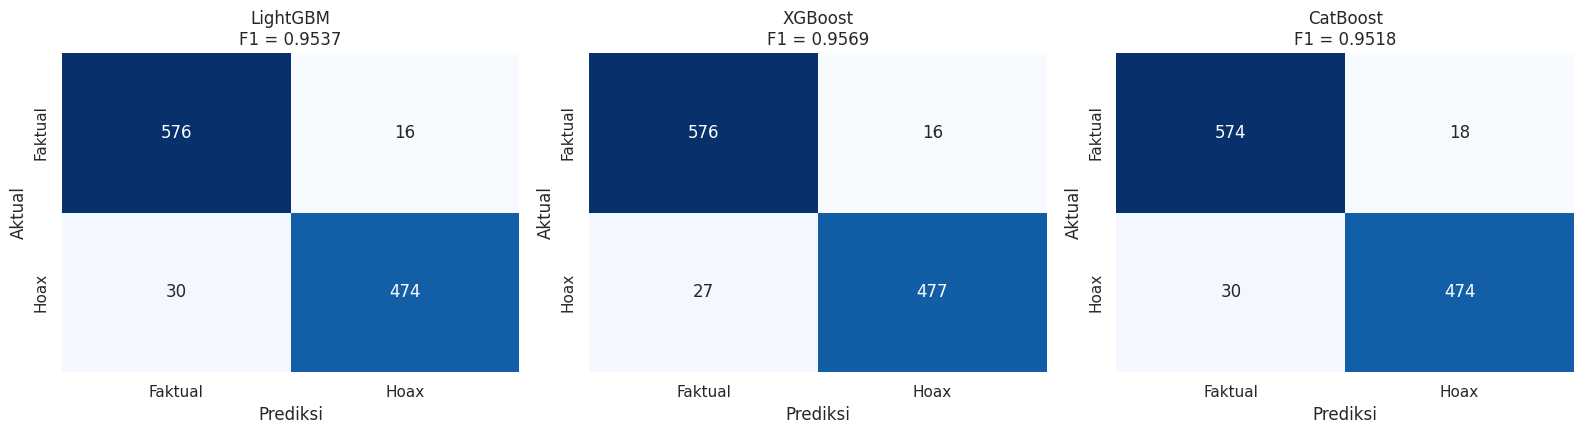

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Faktual", "Hoax"], yticklabels=["Faktual", "Hoax"],
    )
    ax.set_title(f"{name}\nF1 = {f1_score(y_test, preds):.4f}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")

plt.tight_layout()
plt.show()

### 9.2 Bar Chart Perbandingan Metrik

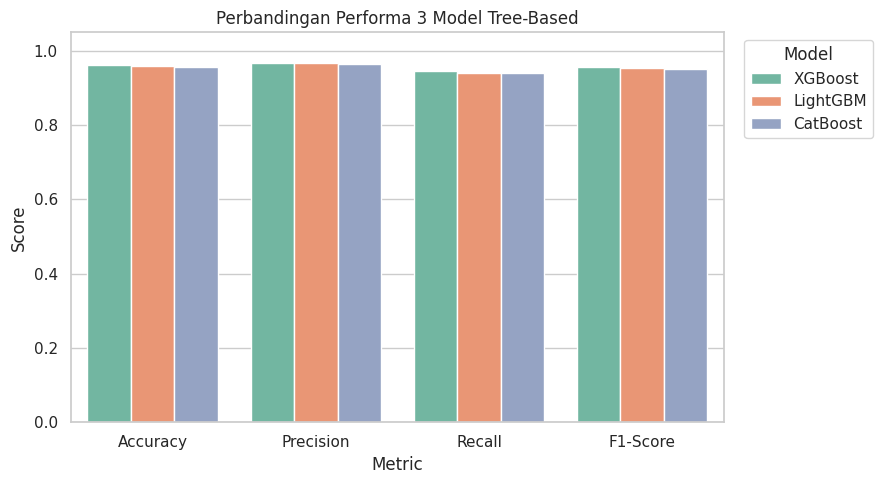

In [39]:
metrics_melted = comparison_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1-Score"],
    var_name="Metric", value_name="Score",
)

plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_melted, x="Metric", y="Score", hue="Model", palette="Set2")
plt.ylim(0, 1.05)
plt.title("Perbandingan Performa 3 Model Tree-Based")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 10. Kesimpulan

In [40]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model_metrics = comparison_df.iloc[0]

print("="*60)
print("RINGKASAN HASIL EKSPERIMEN")
print("="*60)
print(comparison_df_display.to_string(index=False))
print()
print(f"Model dengan performa terbaik (berdasarkan F1-score): {best_model_name}")
print(f"  Accuracy  : {best_model_metrics['Accuracy']:.4f}")
print(f"  Precision : {best_model_metrics['Precision']:.4f}")
print(f"  Recall    : {best_model_metrics['Recall']:.4f}")
print(f"  F1-Score  : {best_model_metrics['F1-Score']:.4f}")

BEST_MODEL = final_models[best_model_name]

RINGKASAN HASIL EKSPERIMEN
   Model  Accuracy  Precision  Recall  F1-Score
 XGBoost    0.9608     0.9675  0.9464    0.9569
LightGBM    0.9580     0.9673  0.9405    0.9537
CatBoost    0.9562     0.9634  0.9405    0.9518

Model dengan performa terbaik (berdasarkan F1-score): XGBoost
  Accuracy  : 0.9608
  Precision : 0.9675
  Recall    : 0.9464
  F1-Score  : 0.9569


### Diskusi Hasil

*(Isi ringkasan di bawah bersifat kerangka umum — sesuaikan angka dan penekanan dengan hasil aktual `comparison_df` pada saat notebook benar-benar dijalankan.)*

- **Model terbaik**: ditentukan otomatis oleh sel kode di atas berdasarkan F1-score tertinggi pada test set (variabel `best_model_name`).
- **Mengapa model tersebut unggul (kerangka umum)**:
  - **CatBoost** menggunakan *ordered boosting* dan *symmetric trees*, yang secara empiris mengurangi risiko overfitting/*prediction shift* dibanding gradient boosting konvensional, khususnya pada dataset berukuran sedang.
  - **LightGBM** menggunakan strategi pertumbuhan pohon *leaf-wise* yang lebih efisien mencapai penurunan loss cepat, namun lebih rentan overfitting bila tidak dibatasi `max_depth`/regularisasi — tuning Optuna berperan penting di sini.
  - **XGBoost** menggunakan pertumbuhan pohon *level-wise* dengan regularisasi eksplisit (L1/L2), cenderung lebih stabil namun kadang butuh lebih banyak estimator untuk mencapai performa setara.
- **Insight dari eksperimen**:
  1. Pembersihan artefak struktural TurnBackHoax (bagian 1.3 & 2) penting agar model belajar dari *konten semantik*, bukan format/genre penulisan atau tag verdict yang bocor ke judul.
  2. Strategi chunking + mean pooling pada embedding SBERT membantu menangkap informasi dari keseluruhan artikel, bukan hanya kalimat pembuka.
  3. Penanganan imbalance kelas melalui `class_weight`/`scale_pos_weight` terbukti membantu meningkatkan recall kelas Hoax dibanding model tanpa penanganan imbalance (bandingkan dengan menjalankan ulang tanpa parameter tersebut sebagai eksperimen tambahan).
  4. Precision vs Recall pada kelas Hoax perlu dipertimbangkan sesuai kebutuhan aplikasi nyata: jika sistem akan digunakan untuk *flagging* otomatis ke pengguna, recall tinggi lebih diprioritaskan (agar hoax tidak lolos); jika digunakan untuk *auto-remove* konten, precision tinggi lebih diprioritaskan (agar berita faktual tidak salah dihapus).

> Untuk laporan/jurnal, ganti paragraf di atas dengan angka dan interpretasi aktual dari hasil run Anda.

## 11. Bonus

### 11.1 Alternatif Penanganan Imbalance: SMOTE (opsional, untuk perbandingan)

Sepanjang notebook ini, penanganan imbalance dilakukan melalui **`class_weight` / `scale_pos_weight`**, yang **lebih disarankan untuk fitur embedding dense** seperti SBERT dibanding **SMOTE**. Alasannya: SMOTE membuat sampel sintetis dengan interpolasi linear antar tetangga terdekat di ruang fitur — pada ruang embedding berdimensi tinggi (384/768 dimensi) yang padat secara semantik, interpolasi ini dapat menghasilkan titik data yang **tidak merepresentasikan kalimat/makna yang valid**, berbeda dengan data tabular biasa.

Meski demikian, sel di bawah menyediakan **demonstrasi SMOTE sebagai pembanding** (opsional, nonaktif secara default).

In [ ]:
# RUN_SMOTE = False  # ubah ke True untuk menjalankan eksperimen pembanding dengan SMOTE

# if RUN_SMOTE:
#     from imblearn.over_sampling import SMOTE

#     smote = SMOTE(random_state=SEED)
#     X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
#     print(f"Shape sebelum SMOTE: {X_train.shape} | Shape sesudah SMOTE: {X_train_smote.shape}")

#     smote_model = CatBoostClassifier(**best_cat_params)
#     smote_model.fit(X_train_smote, y_train_smote)
#     smote_preds = smote_model.predict(X_test)

#     print(f"F1 dengan SMOTE + CatBoost  : {f1_score(y_test, smote_preds):.4f}")
#     print(f"F1 dengan class_weight saja : {comparison_df.set_index('Model').loc['CatBoost', 'F1-Score']:.4f}")
# else:
#     print("RUN_SMOTE=False — lewati eksperimen SMOTE. Ubah flag di atas untuk menjalankan perbandingan.")

### 11.2 Menyimpan Model Terbaik

Kita menyimpan:
1. Model ML (`.pkl` via `joblib`)
2. Nama model SBERT yang digunakan (untuk memuat ulang saat inferensi)
3. Metadata (label mapping, tanggal training, metrik performa)

In [41]:
import joblib

os.makedirs("artifacts", exist_ok=True)

# Simpan ketiga model hasil tuning
saved_model_paths = {}
for name, model in final_models.items():
    path = f"artifacts/model_{name.lower()}.pkl"
    joblib.dump(model, path)
    saved_model_paths[name] = path
    print(f"Model {name} disimpan ke {path}")

# Metadata lengkap: metrik tiap model + penanda model terbaik
metadata = {
    "best_model_name": best_model_name,
    "sbert_model_name": MODEL_NAME,
    "embedding_dim": int(EMBED_DIM),
    "chunk_word_size": CHUNK_WORD_SIZE,
    "max_chunks_per_doc": MAX_CHUNKS_PER_DOC,
    "label_map": {"0": "Faktual", "1": "Hoax"},
    "model_paths": saved_model_paths,
    "test_metrics_per_model": {
        row["Model"]: {
            "accuracy": float(row["Accuracy"]),
            "precision": float(row["Precision"]),
            "recall": float(row["Recall"]),
            "f1_score": float(row["F1-Score"]),
        }
        for _, row in comparison_df.iterrows()
    },
}

with open("artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print()
print("Semua model dan metadata berhasil disimpan di folder 'artifacts/':")
print(os.listdir("artifacts"))

Model LightGBM disimpan ke artifacts/model_lightgbm.pkl
Model XGBoost disimpan ke artifacts/model_xgboost.pkl
Model CatBoost disimpan ke artifacts/model_catboost.pkl

Semua model dan metadata berhasil disimpan di folder 'artifacts/':
['model_xgboost.pkl', 'model_lightgbm.pkl', 'model_catboost.pkl', 'metadata.json']


In [44]:
import os
import json
import joblib
import shutil
from google.colab import files

# ==========================
# Simpan model
# ==========================
os.makedirs("artifacts", exist_ok=True)

saved_model_paths = {}
for name, model in final_models.items():
    path = f"artifacts/model_{name.lower()}.pkl"
    joblib.dump(model, path)
    saved_model_paths[name] = path
    print(f"Model {name} disimpan ke {path}")

# ==========================
# Simpan metadata
# ==========================
metadata = {
    "best_model_name": best_model_name,
    "sbert_model_name": MODEL_NAME,
    "embedding_dim": int(EMBED_DIM),
    "chunk_word_size": CHUNK_WORD_SIZE,
    "max_chunks_per_doc": MAX_CHUNKS_PER_DOC,
    "label_map": {
        "0": "Faktual",
        "1": "Hoax"
    },
    "model_paths": saved_model_paths,
    "test_metrics_per_model": {
        row["Model"]: {
            "accuracy": float(row["Accuracy"]),
            "precision": float(row["Precision"]),
            "recall": float(row["Recall"]),
            "f1_score": float(row["F1-Score"]),
        }
        for _, row in comparison_df.iterrows()
    },
}

with open("artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

# ==========================
# Zip folder artifacts
# ==========================
zip_filename = "artifacts.zip"
shutil.make_archive("artifacts", "zip", "artifacts")

print(f"\nFile {zip_filename} berhasil dibuat.")

# ==========================
# Download otomatis ke laptop
# ==========================
files.download(zip_filename)

Model LightGBM disimpan ke artifacts/model_lightgbm.pkl
Model XGBoost disimpan ke artifacts/model_xgboost.pkl
Model CatBoost disimpan ke artifacts/model_catboost.pkl

File artifacts.zip berhasil dibuat.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 11.3 Fungsi Inferensi Sederhana

Fungsi `predict_news()` di bawah menerima teks berita baru (judul + isi, atau isi saja), melakukan preprocessing yang identik dengan pipeline training, meng-encode dengan model SBERT yang sama, lalu memprediksi label menggunakan model terbaik.

In [42]:
def predict_news(text, title="", model=None, sbert=None):
    '''Prediksi apakah sebuah berita Faktual atau Hoax.

    Parameters
    ----------
    text : str
        Isi/badan berita.
    title : str, optional
        Judul berita (opsional, akan digabung dengan isi).
    model : trained classifier, optional
        Default menggunakan BEST_MODEL hasil training di atas.
    sbert : SentenceTransformer, optional
        Default menggunakan sbert_model yang sudah dimuat.

    Returns
    -------
    dict berisi label prediksi, probabilitas, dan nama model.
    '''
    model = model or BEST_MODEL
    sbert = sbert or sbert_model

    combined_text = f"{title}. {text}" if title else text
    cleaned = general_clean(combined_text)

    embedding = embed_documents([cleaned], sbert)

    pred_label = int(model.predict(embedding)[0])
    pred_proba = model.predict_proba(embedding)[0]

    label_text = "Hoax" if pred_label == 1 else "Faktual"

    return {
        "label": pred_label,
        "label_text": label_text,
        "probability_faktual": float(pred_proba[0]),
        "probability_hoax": float(pred_proba[1]),
        "model_used": best_model_name,
    }


print("Fungsi predict_news() siap digunakan.")

Fungsi predict_news() siap digunakan.


**Contoh penggunaan:**

In [43]:
contoh_judul = "Foto Presiden Membagikan Uang Tunai di Acara Kampanye"
contoh_isi = (
    "Beredar sebuah foto di media sosial yang menunjukkan presiden membagikan uang tunai "
    "kepada warga di sebuah acara kampanye. Namun setelah ditelusuri, foto tersebut "
    "merupakan hasil suntingan dan tidak ada acara pembagian uang tunai yang benar-benar terjadi."
)

result = predict_news(contoh_isi, title=contoh_judul)
print(json.dumps(result, indent=2, ensure_ascii=False))

Total dokumen: 1 | Total chunk yang akan di-encode: 1


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

{
  "label": 1,
  "label_text": "Hoax",
  "probability_faktual": 3.230571746826172e-05,
  "probability_hoax": 0.9999676942825317,
  "model_used": "XGBoost"
}


---

## Penutup

Notebook ini mencakup seluruh tahapan yang diminta: data loading & integration (dengan koreksi label berbasis verdict tag), preprocessing (ringan untuk SBERT + jalur lengkap Sastrawi untuk dokumentasi), embedding semantik (SBERT multilingual dengan chunking), pelatihan & tuning 3 model tree-based dengan Optuna, evaluasi lengkap, perbandingan model, visualisasi, kesimpulan otomatis berbasis data, serta bonus (penanganan imbalance, penyimpanan model, fungsi inferensi).

**Saran pengembangan lanjutan:**
- Tambahkan **cross-validation** pada evaluasi akhir (bukan hanya single train-test split) untuk estimasi performa yang lebih stabil.
- Lakukan **error analysis** manual pada kasus false positive/false negative untuk memahami pola kesalahan model.
- Coba **model embedding lain** (mis. IndoBERT, `paraphrase-multilingual-mpnet-base-v2`) untuk melihat apakah representasi semantik yang lebih kaya meningkatkan performa.
- Jika ingin membandingkan dengan pendekatan klasik, gunakan kolom `text_processed` (hasil Sastrawi) sebagai input **TF-IDF** sebagai baseline pembanding terhadap SBERT.